In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
import joblib
from imblearn.over_sampling import SMOTENC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import optuna
from sklearn.model_selection import KFold, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
from tabulate import tabulate
import json
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import PartialDependenceDisplay
from itertools import combinations


In [2]:
bank= pd.read_csv("/kaggle/input/datasets/prahazra/final-bank-data/Final_bank_data.csv")

In [3]:
X_train, x_test,Y_train, y_test= train_test_split(bank.drop('Exited', axis=1), bank['Exited'], test_size=0.2, random_state=42)

In [4]:
columns= X_train.columns
categorical_cols= []
numerical_cols= []
for col in columns:
  if bank[col].dtype == 'object' or bank[col].dtype == 'category':
    categorical_cols.append(col)
  else:
    numerical_cols.append(col)

In [5]:
smote_nc = SMOTENC(categorical_features=categorical_cols, random_state=42)
X_train_resampled, Y_train_resampled = smote_nc.fit_resample(X_train, Y_train)

In [6]:
preprocessor= joblib.load('/kaggle/input/notebooks/prahazra/model-optimization/preprocessor.joblib')

In [7]:
X_train= preprocessor.transform(X_train_resampled)
x_test= preprocessor.transform(x_test)

In [8]:
X_train

array([[ 0.        ,  0.        ,  1.        , ..., -0.03549985,
         2.56872076, -0.3295033 ],
       [ 1.        ,  0.        ,  1.        , ..., -0.03549985,
        -0.38929883, -0.3295033 ],
       [ 0.        ,  1.        ,  1.        , ..., -0.03549985,
        -0.38929883, -0.3295033 ],
       ...,
       [ 0.        ,  0.        ,  1.        , ..., -0.03549985,
        -0.38929883, -0.3295033 ],
       [ 1.        ,  0.        ,  0.        , ..., -0.03549985,
        -0.38929883,  3.03487096],
       [ 1.        ,  0.        ,  1.        , ..., -0.03549985,
        -0.38929883, -0.3295033 ]], shape=(12712, 39))

# Model Fitting

In [9]:
def load_params(file_path):
    with open(file_path, "r") as f:
        params_dict = json.load(f)
    print(f"Successfully loaded from: {file_path}")
    return params_dict

In [10]:
LR_params= load_params("/kaggle/input/notebooks/prahazra/model-optimization/LR_params1.json")
LR_params['penalty'] = LR_params.pop('penalty_standard')
LR_params

Successfully loaded from: /kaggle/input/notebooks/prahazra/model-optimization/LR_params1.json


{'solver': 'sag',
 'C': 0.0006284853400615115,
 'tol': 3.3830102193537486e-05,
 'max_iter': 219,
 'penalty': None}

In [11]:
LR_classifier= LogisticRegression(**LR_params, random_state= 42)
LR_classifier.fit(X_train, Y_train_resampled)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(C=0.0006284853400615115, max_iter=219, penalty=None,
                   random_state=42, solver='sag', tol=3.3830102193537486e-05)

In [12]:
GB_params= load_params("/kaggle/input/notebooks/prahazra/model-optimization/GB_params1.json")
GB_params['max_features'] = GB_params.pop('max_features_gb_float')
del GB_params["max_features_option"]
GB_params

Successfully loaded from: /kaggle/input/notebooks/prahazra/model-optimization/GB_params1.json


{'loss': 'exponential',
 'learning_rate': 0.0968451849110919,
 'n_estimators': 204,
 'criterion': 'friedman_mse',
 'min_samples_split': 16,
 'min_impurity_decrease': 0.14407872703384905,
 'max_depth': 6,
 'max_features': 0.6210584689442419}

In [13]:
GB_classifier= GradientBoostingClassifier(**GB_params, random_state= 42)
GB_classifier.fit(X_train, Y_train_resampled)

GradientBoostingClassifier(learning_rate=0.0968451849110919, loss='exponential',
                           max_depth=6, max_features=0.6210584689442419,
                           min_impurity_decrease=0.14407872703384905,
                           min_samples_split=16, n_estimators=204,
                           random_state=42)

In [14]:
XGB_params= load_params("/kaggle/input/notebooks/prahazra/model-optimization/XGB_params1.json")
XGB_params

Successfully loaded from: /kaggle/input/notebooks/prahazra/model-optimization/XGB_params1.json


{'n_estimators': 286,
 'max_depth': 7,
 'grow_policy': 'depthwise',
 'learning_rate': 0.05992504425893089,
 'booster': 'dart',
 'gamma': 0.20863374548014635,
 'min_child_weight': 4}

In [15]:
XGB_classifier= XGBClassifier(**XGB_params, random_state= 42,eval_metric = 'logloss')
XGB_classifier.fit(X_train, Y_train_resampled)

XGBClassifier(base_score=None, booster='dart', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None,
              gamma=0.20863374548014635, grow_policy='depthwise',
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05992504425893089, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=4, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=286, n_jobs=None,
              num_parallel_tree=None, ...)

# Model Evaluation

In [16]:
LR_pred= LR_classifier.predict(x_test)
GB_pred= GB_classifier.predict(x_test)
XGB_pred= XGB_classifier.predict(x_test)

In [17]:
LR_report= classification_report(y_test,LR_pred)
GB_report= classification_report(y_test,GB_pred)
XGB_report= classification_report(y_test,XGB_pred)

In [18]:
print(f"Logistic Regression\n{LR_report}")
print(f"Gradient Boosting Classifier\n{GB_report}")
print(f"XGBoost Classifier\n{XGB_report}")

Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      1607
           1       0.53      0.60      0.56       393

    accuracy                           0.82      2000
   macro avg       0.71      0.73      0.72      2000
weighted avg       0.83      0.82      0.82      2000

Gradient Boosting Classifier
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      1607
           1       0.67      0.54      0.60       393

    accuracy                           0.86      2000
   macro avg       0.78      0.74      0.76      2000
weighted avg       0.85      0.86      0.85      2000

XGBoost Classifier
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      1607
           1       0.70      0.54      0.61       393

    accuracy                           0.86      2000
   macro avg       0.80      0.74      0.76      2000
weight

**From the classification report we can make the following inference.**
- Both the boosting algorithms are performing significantly better than the base line model in accuracy as well as other metrices like precision, recall, F1 score etc.
- Since, both the boosting models performing quite similar, we have to look at the tiniest details to choose one.
- Both the model have same precision for class 0, i.e the class where a customer is retained. But XGBoost have slightly **higher precision for class 1** i.e. XGBoost captures the churn probability better for those who are prone to churn.
- On the other hand **XGBoost has better macro avg. precision** indicating that it can **balance both classes better** than Gradient Boosting. Also, XGBoost runs faster and uses system memory much better than standard Gradient Boosting.

Hence, we will select XGBoost as our final model.

In [19]:
joblib.dump(XGB_classifier, 'classifier.joblib')

['classifier.joblib']

# Model Explainability Analysis

In [20]:
importances= XGB_classifier.feature_importances_
encoded_columns = preprocessor.get_feature_names_out()
feature_df = pd.DataFrame(
    {"Feature": encoded_columns, "Importance": importances}
).sort_values(by="Importance", ascending=True)

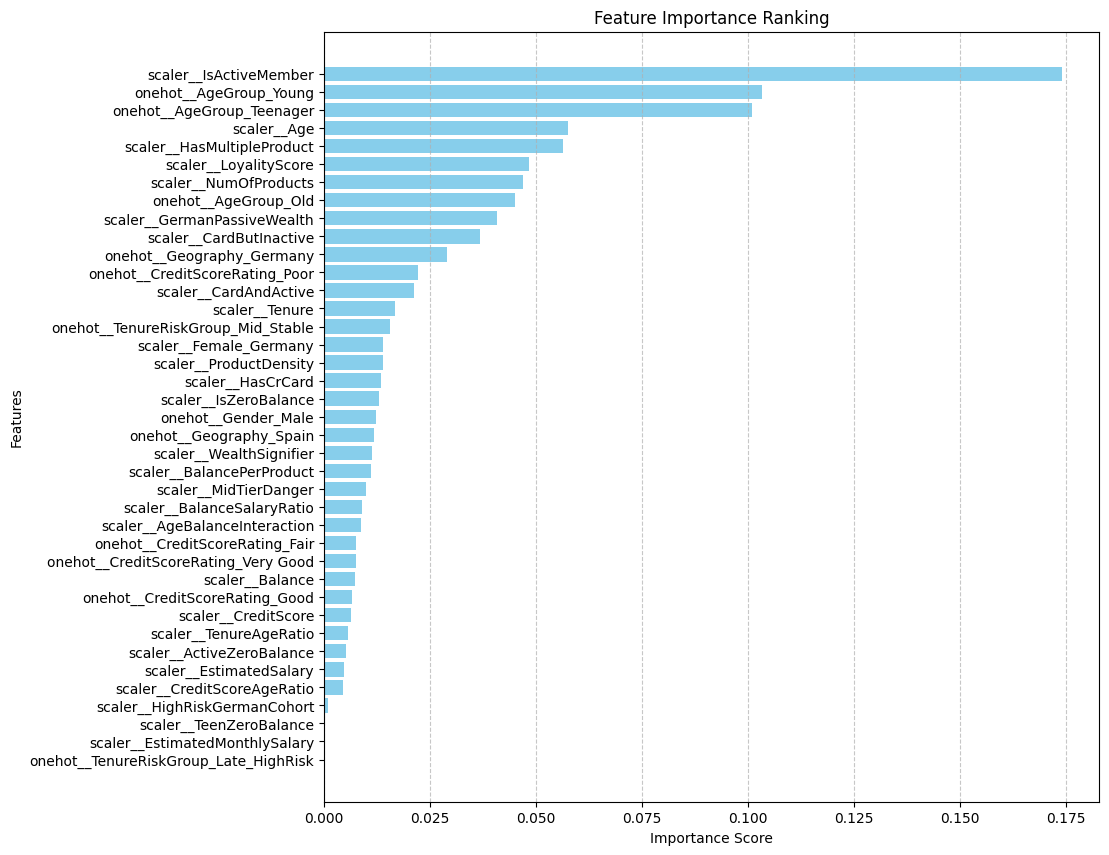

In [21]:
plt.figure(figsize=(10, 10))
plt.barh(feature_df["Feature"], feature_df["Importance"], color="skyblue")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance Ranking")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

We can see that the most important features for the model are, age group and if he/she is an active member or not. Let's look at the features further to know how they are impacting the prediction.

## SHAP value analysis

In [22]:
explainer= shap.TreeExplainer(XGB_classifier)
shap_values = explainer(x_test)
shap_values.feature_names= list(encoded_columns)

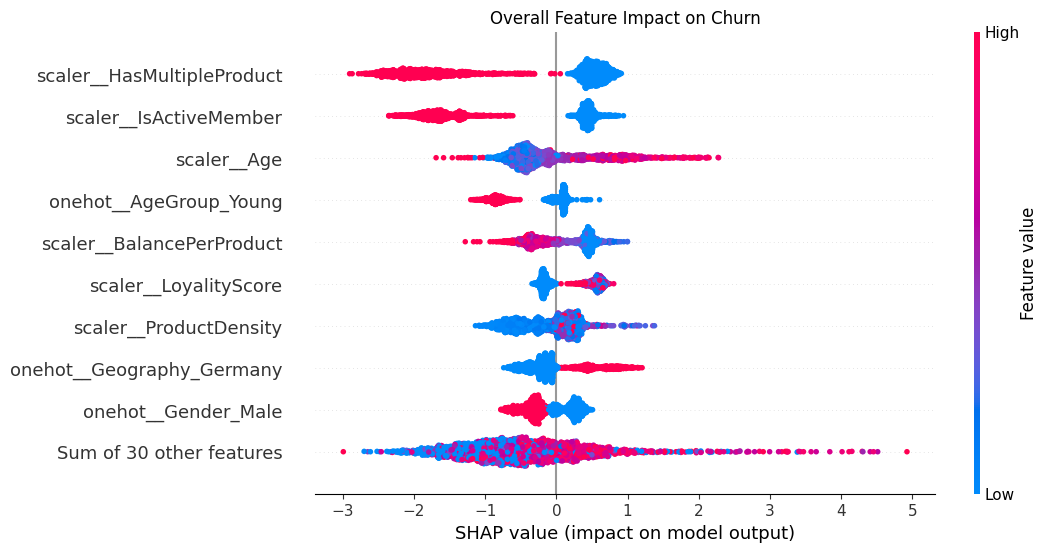

In [23]:
plt.title("Overall Feature Impact on Churn")
shap.plots.beeswarm(shap_values,max_display= 10, show= False,plot_size= (10,6))
plt.show()

- We can see **NumOfProducts** is the most important feature. This means customers with fewer bank products are much more likely to leave.
- Active members (red dots) cluster heavily on the left side. This shows that **keeping customers active in their accounts strongly prevents them from churning.**
- Younger customers (red dots) sit on the left side. This tells us that **younger clients are loyal and tend to stay with the bank.**
- German customers (red dots) push far to the right side. This reveals a location risk: **customers living in Germany have a much higher chance of leaving.**
- Male customers (blue/purple dots) push to the right, while female customers (red dots) cluster on the left. This implies that **male customers are more likely to churn than female customers.**
- ProductDensity and BalancePerProduct, these engineered features, are highly important. Low product density and high balances per product push customers toward churning. This means **customers who store a lot of money in just one or two places are highly sensitive to leaving.**
-   For the Age feature, there is a long tail of red dots stretching all the way to +2.5. This confirms that **older customers represent a very high churn risk for the bank.**

Let's look at the partial dependence plots for all the top 10 features.

In [24]:
global_importances = np.abs(shap_values.values).mean(axis=0)

shap_importance_df = pd.DataFrame(
    {"feature": shap_values.feature_names, "importance": global_importances}
).sort_values(by="importance", ascending=False)

top_10_features = shap_importance_df["feature"].head(10).tolist()
print(f"Top 10 Features Selected: {top_10_features}")

Top 10 Features Selected: ['scaler__HasMultipleProduct', 'scaler__IsActiveMember', 'scaler__Age', 'onehot__AgeGroup_Young', 'scaler__BalancePerProduct', 'scaler__LoyalityScore', 'scaler__ProductDensity', 'onehot__Geography_Germany', 'onehot__Gender_Male', 'scaler__Balance']


In [25]:
feature_pairs = list(combinations(top_10_features, 2))
print(f"Total interaction plots generated: {len(feature_pairs)}")
X_train_df = pd.DataFrame(X_train, columns=shap_values.feature_names)

Total interaction plots generated: 45


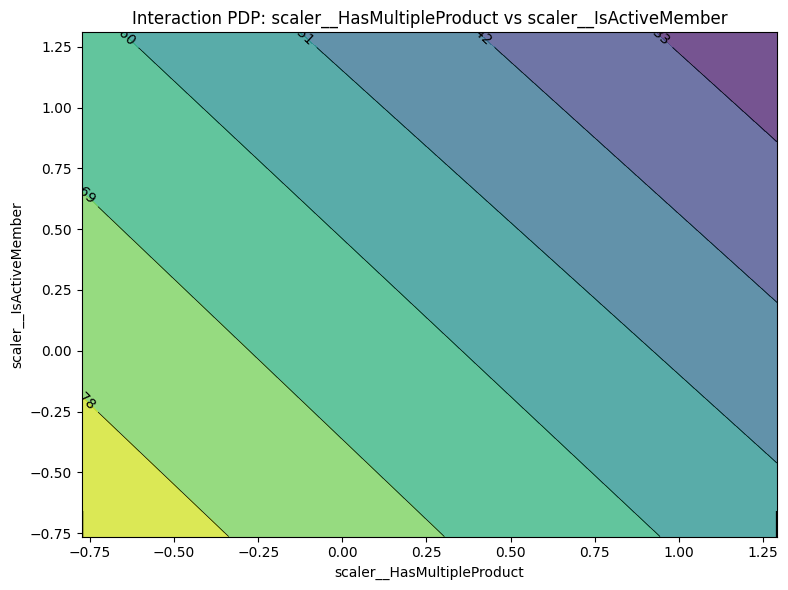

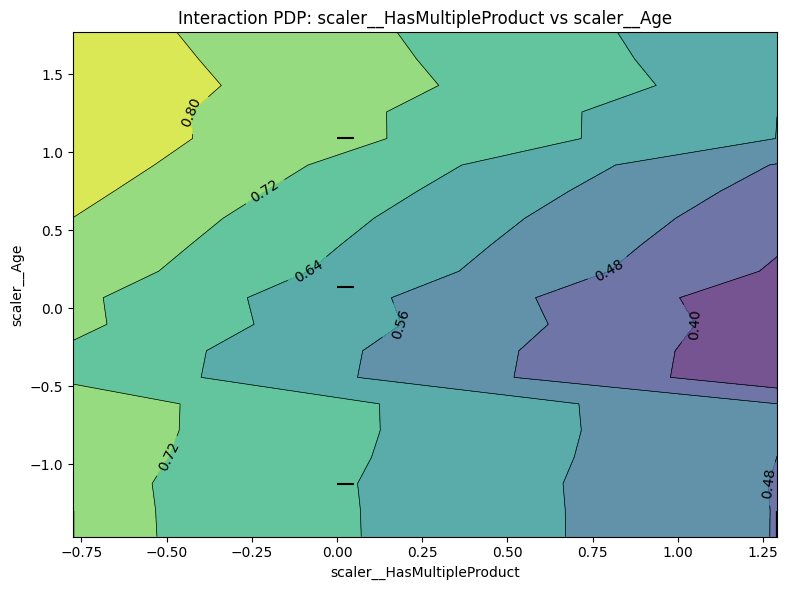

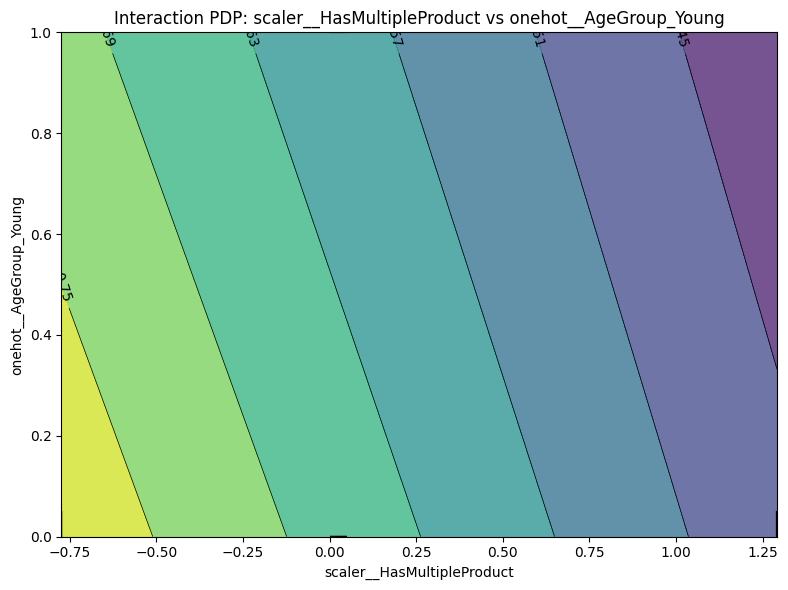

In [26]:
for pair in feature_pairs[:3]:  # Change [:3] to see more or all combinations
    fig, ax = plt.subplots(figsize=(8, 6))

    PartialDependenceDisplay.from_estimator(
        estimator=XGB_classifier,
        X=X_train_df,
        features=[pair],  
        grid_resolution=20,  
        ax=ax,
    )

    plt.title(f"Interaction PDP: {pair[0]} vs {pair[1]}")
    plt.tight_layout()
    plt.show()

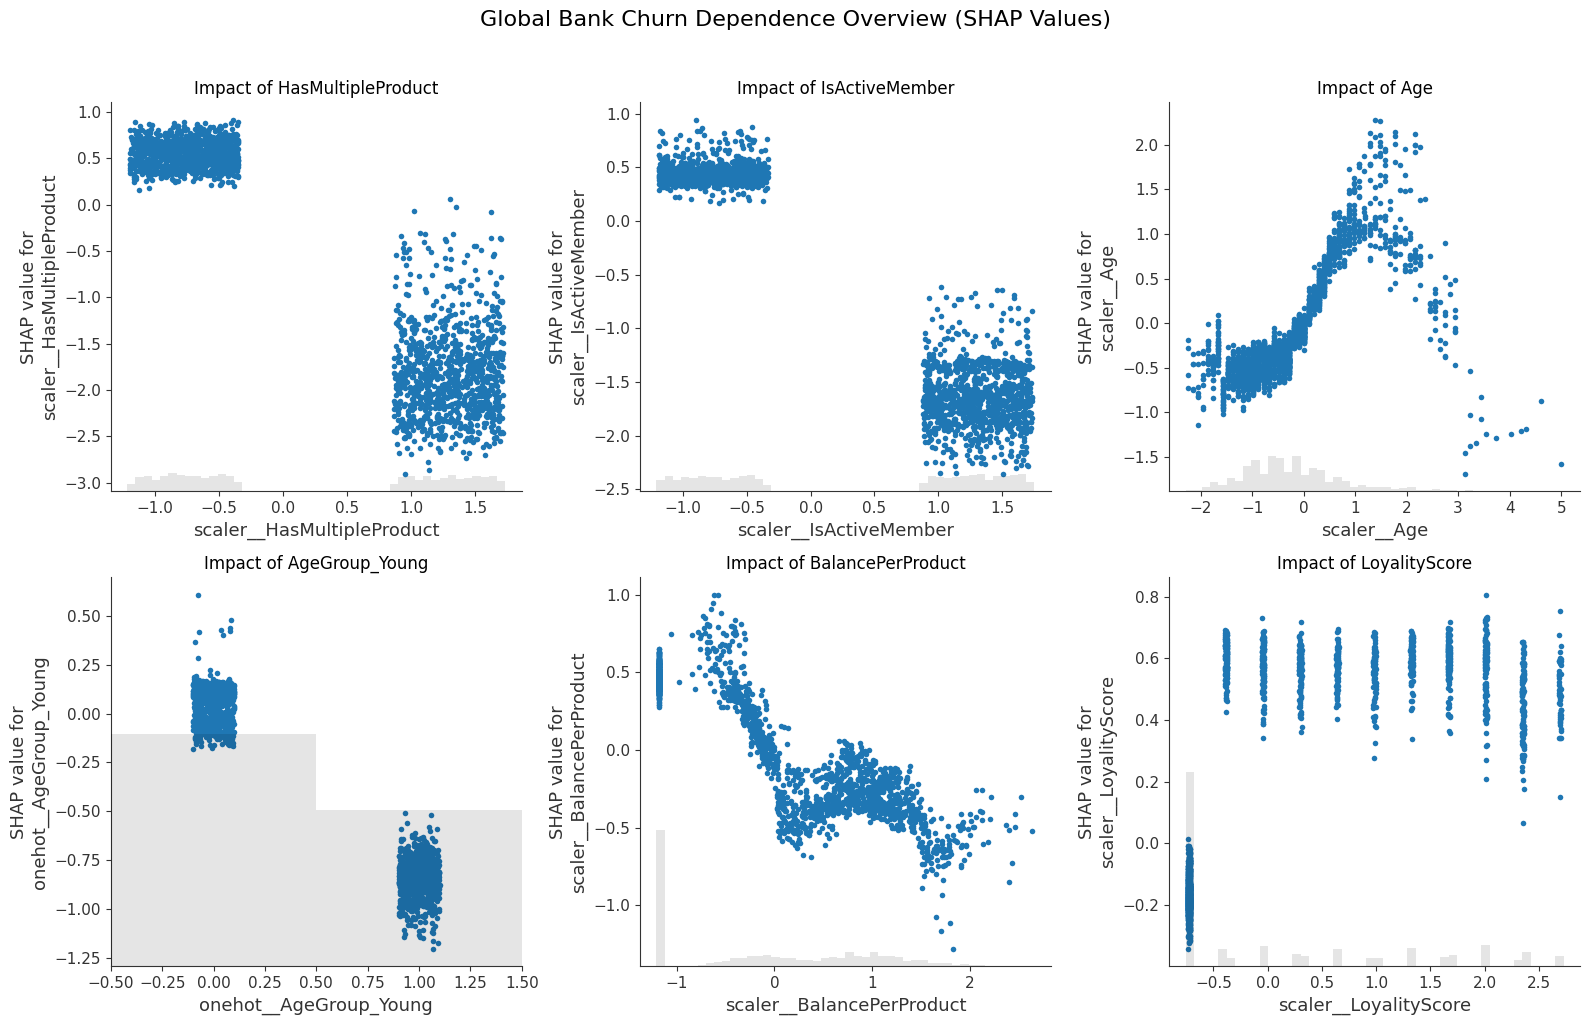

In [27]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten() 
features_to_plot = top_10_features[:6]
for i, feature_name in enumerate(features_to_plot):
    shap.plots.scatter(
        shap_values[:, feature_name], color=None, ax=axes[i], show=False
    )
    axes[i].set_title(f"Impact of {feature_name.split('__')[-1]}")

plt.suptitle(
    "Global Bank Churn Dependence Overview (SHAP Values)",
    fontsize=16,
    y=1.02,
)
plt.tight_layout()
plt.savefig("bank_churn_shap_dependence.png", dpi=300, bbox_inches="tight")
plt.show()

- Having exactly 1 product strongly keeps customers from leaving, while holding 3 or 4 products triggers a massive risk spike that drives them to churn.
- Inactive account holders are highly likely to leave, whereas keeping an account active acts as a powerful shield that prevents churn.
- Younger clients are highly stable and loyal to the bank, while older age brackets carry a steady, increased risk of exiting.
- Low product density keeps customers securely retained, but as density climbs, the risk of losing the customer shoots up dramatically.
- Low balances per product push customers to leave, while a higher balance spread across products makes customers far more secure and likely to stay.
- Living outside of Germany keeps customers safe and stable, while being located in Germany serves as a massive, independent trigger for churning.


### Recomendations

- **Execute a Regional Operational Audit in Germany:** Location analysis reveals that living in Germany acts as a severe, independent driver for client exits. The bank must investigate localized pain points in German branches—such as aggressive competitor interest rates, local fee structures, or regional app performance—to eliminate this geographic risk.
- **Redesign the Multi-Product Customer Journey:** While holding a single product provides strong account stability, churn risk spikes dramatically when a client holds 3 or 4 bank products. The product team should review the user experience for these multi-product holders to ensure they are not experiencing service fatigue, overlapping fees, or poor communication across their bundled accounts.
- **Deploy an Automated Inactivity Reactivation Pipeline:** Account inactivity is a critical risk indicator, whereas active membership serves as a powerful shield against churn. The bank should launch automated, behavioral-triggered campaigns (such as mobile app engagement rewards or personalized fee waivers) the moment a client’s transaction or login frequency drops past a threshold.
- **Introduce a Transitionary Lifecycle Retention Strategy:** The data confirms that younger clients are highly stable, but churn risk begins a steady climb as clients age into their mid-40s and 50s. The marketing team should proactively target this aging demographic with milestone-based financial products—such as wealth management planning or loyalty-based mortgage discounts—to adapt to their shifting financial needs.
- **Enforce Safe Cross-Selling Guardrails for 1-Product Clients:** Because clients with exactly 1 product are currently highly secure, the sales team must avoid aggressive, unoptimized cross-selling that pushes them prematurely into the high-risk multi-product zone. Any secondary product offered must be paired with high-yield incentives to intentionally increase the client's overall balance per product, which the model flags as a key anchor for long-term customer retention.
